In [1]:
#Importing packages
from transformers import ViTModel, ViTImageProcessor
import torch
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import chromadb
import matplotlib.pyplot as plt
import numpy as np

#Import library code
import helper_code.dataloading as dataloading
import helper_code.model_functions as model_functions
import helper_code.data_vis as data_vis

d:\Projects\alertcalifornia-anomaly-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_camera_embeddings(labels_csv, embeddings_name):
    image_dir = "camera_data/images/"
    data = dataloading.get_data(labels_csv=labels_csv, image_dir=image_dir)
    train, val, test = dataloading.get_train_val_test(data = data, output_csvs=True)
    embeddings, labels, img_urls, a_ids = dataloading.load_full_embeddings(train, embeddings_name)
    reduced_embeddings, labels = model_functions.reduce_pca(embeddings, labels)

    return reduced_embeddings, labels, img_urls, a_ids

In [ ]:
labels_csv = r"camera_data\coronado_hills_data.csv"
embeddings_name = "train_embeddings"

reduced_embeddings, labels, _, _ = get_camera_embeddings(labels_csv=labels_csv, embeddings_name=embeddings_name)

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Aneesh\AppData\Local\Temp\ipykernel_29460\3406415567.py:1: SyntaxWarning: invalid escape sequence '\c'
  labels_csv = "camera_data\coronado_hills_ranked.csv"
  0%|          | 0/2748 [00:00<?, ?it/s]

100%|██████████| 2748/2748 [00:00<00:00, 6898.26it/s]


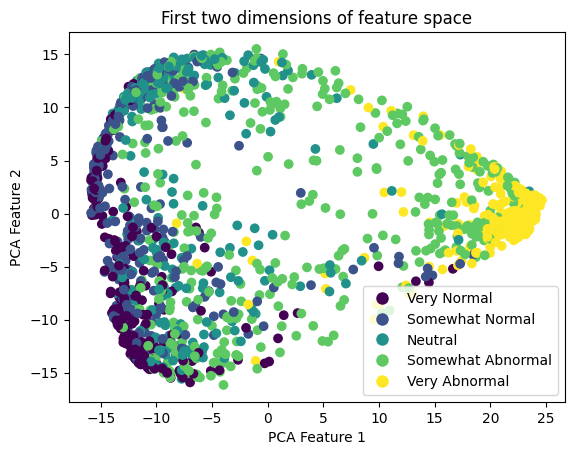

In [20]:
sc = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c = labels)

size = 81 

lp = lambda i: plt.plot([],color=sc.cmap(sc.norm(i)), ms=np.sqrt(size), mec="none",
                        label="{l}".format(l = "Very Normal" if i == 0 
                                           else "Somewhat Normal" if i == 1 
                                           else "Neutral" if i == 2
                                           else "Somewhat Abnormal" if i == 3
                                           else "Very Abnormal"), ls="", marker="o")[0]
handles = [lp(i) for i in np.unique(labels)]
plt.legend(handles = handles)
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.title("First two dimensions of feature space")
plt.show()